# Treinamento de Modelos de Machine Learning

Este notebook realiza o treinamento e avaliação de modelos de Machine Learning para detecção de lavagem de dinheiro.

**Técnicas aplicadas:**
1. **Carregamento dos dados processados**
2. **Análise do desbalanceamento das classes**
3. **Balanceamento usando RUS (Random Under Sampling)**
4. **Criação de Pipelines (evitar data leakage)**
5. **Treinamento de múltiplos algoritmos:**
   - Logistic Regression
   - Random Forest
   - XGBoost
   - LightGBM
   - Gradient Boosting
6. **Avaliação e comparação de modelos**
7. **Análise de feature importance**
8. **Validação no conjunto OOT (Out-of-Time)**

## 0. Instalação de Bibliotecas

Instalando bibliotecas necessárias para treinamento.

In [11]:
# Instalar bibliotecas necessárias
!pip install -q imbalanced-learn xgboost lightgbm
print("✅ Bibliotecas instaladas com sucesso!")

✅ Bibliotecas instaladas com sucesso!



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Modelos e Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, 
    accuracy_score, precision_score, recall_score, average_precision_score
)

# Imbalanced-learn para balanceamento
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost e LightGBM
import xgboost as xgb
import lightgbm as lgb

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

Carregando os datasets de treino e OOT já processados e preparados.

In [16]:
# Carregar dados processados
print("="*80)
print("CARREGAMENTO DOS DADOS")
print("="*80)

try:
    # Carregar features (X) e target (y)
    X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
    
    # Carregar y_train como DataFrame primeiro
    y_train_df = pd.read_csv('../data/processed/y_train.csv')
    # Pegar a coluna que não é índice
    y_col = [col for col in y_train_df.columns if col not in ['Unnamed: 0', 'index']][0]
    y_train = y_train_df[y_col]

    X_oot = pd.read_csv('../data/processed/X_oot.csv', index_col=0)
    
    # Carregar y_oot como DataFrame primeiro
    y_oot_df = pd.read_csv('../data/processed/y_oot.csv')
    # Pegar a coluna que não é índice
    y_col_oot = [col for col in y_oot_df.columns if col not in ['Unnamed: 0', 'index']][0]
    y_oot = y_oot_df[y_col_oot]
    
    # Verificar se há valores ausentes
    if X_train.isnull().sum().sum() > 0:
        print("\n⚠️ Aviso: Existem valores ausentes em X_train. Preenchendo com 0...")
        X_train = X_train.fillna(0)
    
    if X_oot.isnull().sum().sum() > 0:
        print("\n⚠️ Aviso: Existem valores ausentes em X_oot. Preenchendo com 0...")
        X_oot = X_oot.fillna(0)
    
    # Garantir que todas as colunas são numéricas ANTES de verificar infinitos
    non_numeric_train = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    non_numeric_oot = X_oot.select_dtypes(exclude=[np.number]).columns.tolist()
    
    if non_numeric_train:
        print(f"\n⚠️ Removendo colunas não-numéricas de X_train: {non_numeric_train}")
        X_train = X_train.select_dtypes(include=[np.number])
    
    if non_numeric_oot:
        print(f"\n⚠️ Removendo colunas não-numéricas de X_oot: {non_numeric_oot}")
        X_oot = X_oot.select_dtypes(include=[np.number])
    
    # Verificar e corrigir valores infinitos (DEPOIS de garantir que são numéricos)
    if np.isinf(X_train.values).sum() > 0:
        print("\n⚠️ Aviso: Existem valores infinitos em X_train. Substituindo...")
        X_train = X_train.replace([np.inf, -np.inf], 0)
    
    if np.isinf(X_oot.values).sum() > 0:
        print("\n⚠️ Aviso: Existem valores infinitos em X_oot. Substituindo...")
        X_oot = X_oot.replace([np.inf, -np.inf], 0)
    
    # Garantir que as colunas sejam as mesmas em treino e OOT
    common_cols = X_train.columns.intersection(X_oot.columns)
    X_train = X_train[common_cols]
    X_oot = X_oot[common_cols]

    print(f"\n📊 Dados de Treino:")
    print(f"   X_train shape: {X_train.shape}")
    print(f"   y_train shape: {y_train.shape}")
    print(f"   Memória X_train: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\n📊 Dados de OOT (Out-of-Time):")
    print(f"   X_oot shape: {X_oot.shape}")
    print(f"   y_oot shape: {y_oot.shape}")
    print(f"   Memória X_oot: {X_oot.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\n📋 Primeiras linhas de X_train:")
    display(X_train.head())

    print(f"\n📋 Distribuição da variável target:")
    display(y_train.value_counts())
    
    print(f"\n✅ Dados carregados com sucesso!")
    
except FileNotFoundError as e:
    print(f"\n❌ Erro: Arquivo não encontrado - {e}")
    print("Certifique-se de que o notebook de feature engineering foi executado.")
    raise
except Exception as e:
    print(f"\n❌ Erro ao carregar dados: {e}")
    raise

CARREGAMENTO DOS DADOS

⚠️ Removendo colunas não-numéricas de X_train: ['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash', 'Payment Format_Cheque', 'Payment Format_Credit Card', 'Payment Format_Reinvestment', 'Payment Format_Wire']

⚠️ Removendo colunas não-numéricas de X_oot: ['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash', 'Payment Format_Cheque', 'Payment Format_Credit Card', 'Payment Format_Wire']

📊 Dados de Treino:
   X_train shape: (25001186, 18)
   y_train shape: (25001186,)
   Memória X_train: 3624.13 MB

📊 Dados de OOT (Out-of-Time):
   X_oot shape: (6250297, 18)
   y_oot shape: (6250297,)
   Memória X_oot: 906.03 MB

📋 Primeiras linhas de X_train:


,To Bank,Amount Received,Amount Paid,Bank ID,Bank ID_To,Receiving Currency_target_enc,Payment Currency_target_enc,Timestamp_freq_enc,From Account_freq_enc,To Account_freq_enc,From Bank Name_freq_enc,Account Number_freq_enc,From Entity ID_freq_enc,From Entity Name_freq_enc,To Bank Name_freq_enc,Account Number_To_freq_enc,To Entity ID_freq_enc,To Entity Name_freq_enc
From Bank,,,,,,,,,,,,,,,,,,
26.531808,40.848958,5.415905,5.431333,26.531808,40.848958,0.000387,0.000392,0.001714,0.000001,0.000000,0.000609,0.000001,0.000003,0.000003,0.000488,0.000000,0.000002,0.000002
30.680528,49.209532,7.844239,7.877808,30.680528,49.209532,0.000501,0.000497,0.001714,0.000000,0.000000,0.001197,0.000000,0.000001,0.000001,0.001128,0.000000,0.000001,0.000001
39.972279,69.455230,10.259549,10.319281,39.972279,69.455230,0.000501,0.000497,0.001714,0.000000,0.000000,0.001705,0.000000,0.000000,0.000000,0.002119,0.000000,0.000000,0.000000
23.477685,34.983297,11.242472,11.315431,23.477685,34.983297,0.000501,0.000497,0.001714,0.000000,0.000000,0.001988,0.000000,0.000000,0.000000,0.002202,0.000000,0.000000,0.000000
27.412702,42.587073,9.838657,9.893199,27.412702,42.587073,0.000392,0.000398,0.001714,0.000001,0.000003,0.000073,0.000001,0.000001,0.000001,0.000117,0.000003,0.000003,0.000003



📋 Distribuição da variável target:


Is Laundering
0    24988928
1       12258
Name: count, dtype: int64


✅ Dados carregados com sucesso!


## 2. Análise do Desbalanceamento

Analisando a distribuição das classes nos dados de treino e OOT.

ANÁLISE DE DESBALANCEAMENTO DAS CLASSES

📊 Distribuição no conjunto de TREINO:
   Classe 0: 24,988,928 amostras (99.95%)
   Classe 1: 12,258 amostras (0.05%)

📊 Distribuição no conjunto OOT:
   Classe 0: 6,246,514 amostras (99.94%)
   Classe 1: 3,783 amostras (0.06%)

📊 Métricas de Desbalanceamento:
   Classe Majoritária: 0 (24,988,928 amostras)
   Classe Minoritária: 1 (12,258 amostras)
   Razão de Desbalanceamento: 2038.58:1


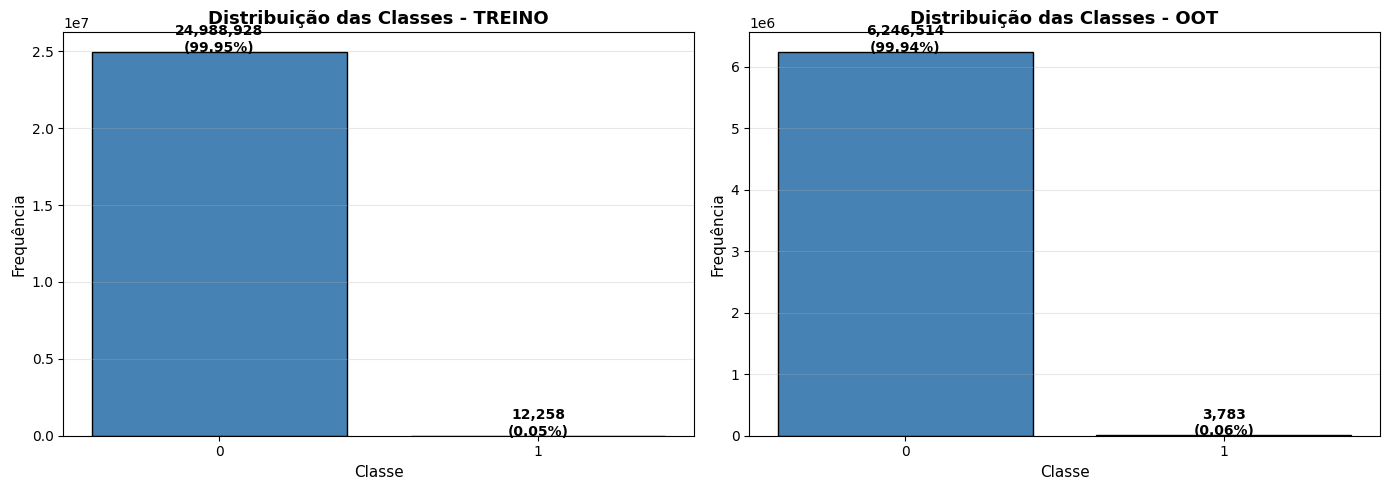

In [17]:
# Análise de desbalanceamento
print("="*80)
print("ANÁLISE DE DESBALANCEAMENTO DAS CLASSES")
print("="*80)

# Treino
print(f"\n📊 Distribuição no conjunto de TREINO:")
train_distribution = y_train.value_counts()
train_distribution_pct = y_train.value_counts(normalize=True) * 100

for cls, count in train_distribution.items():
    pct = train_distribution_pct[cls]
    print(f"   Classe {cls}: {count:,} amostras ({pct:.2f}%)")

# OOT
print(f"\n📊 Distribuição no conjunto OOT:")
oot_distribution = y_oot.value_counts()
oot_distribution_pct = y_oot.value_counts(normalize=True) * 100

for cls, count in oot_distribution.items():
    pct = oot_distribution_pct[cls]
    print(f"   Classe {cls}: {count:,} amostras ({pct:.2f}%)")

# Calcular razão de desbalanceamento
if len(train_distribution) == 2:
    majority_class = train_distribution.idxmax()
    minority_class = train_distribution.idxmin()
    imbalance_ratio = train_distribution[majority_class] / train_distribution[minority_class]
    
    print(f"\n📊 Métricas de Desbalanceamento:")
    print(f"   Classe Majoritária: {majority_class} ({train_distribution[majority_class]:,} amostras)")
    print(f"   Classe Minoritária: {minority_class} ({train_distribution[minority_class]:,} amostras)")
    print(f"   Razão de Desbalanceamento: {imbalance_ratio:.2f}:1")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Treino
axes[0].bar(train_distribution.index.astype(str), train_distribution.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Distribuição das Classes - TREINO', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
for i, (cls, count) in enumerate(train_distribution.items()):
    pct = train_distribution_pct[cls]
    axes[0].text(i, count + 100, f'{count:,}\n({pct:.2f}%)', ha='center', fontweight='bold')

# OOT
axes[1].bar(oot_distribution.index.astype(str), oot_distribution.values, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Distribuição das Classes - OOT', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].grid(alpha=0.3, axis='y')
for i, (cls, count) in enumerate(oot_distribution.items()):
    pct = oot_distribution_pct[cls]
    axes[1].text(i, count + 50, f'{count:,}\n({pct:.2f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Balanceamento com RUS (Random Under Sampling)

Aplicando Random Under Sampling para balancear os dados de treino.

BALANCEAMENTO COM RANDOM UNDER SAMPLING (RUS)

📊 Dados ANTES do balanceamento:
   Shape: (25001186, 18)
   Distribuição: {0: 24988928, 1: 12258}

📊 Dados DEPOIS do balanceamento:
   Shape: (24516, 18)
   Distribuição: {0: 12258, 1: 12258}

📊 Estatísticas do Balanceamento:
   Amostras originais: 25,001,186
   Amostras balanceadas: 24,516
   Amostras removidas: 24,976,670 (99.90%)


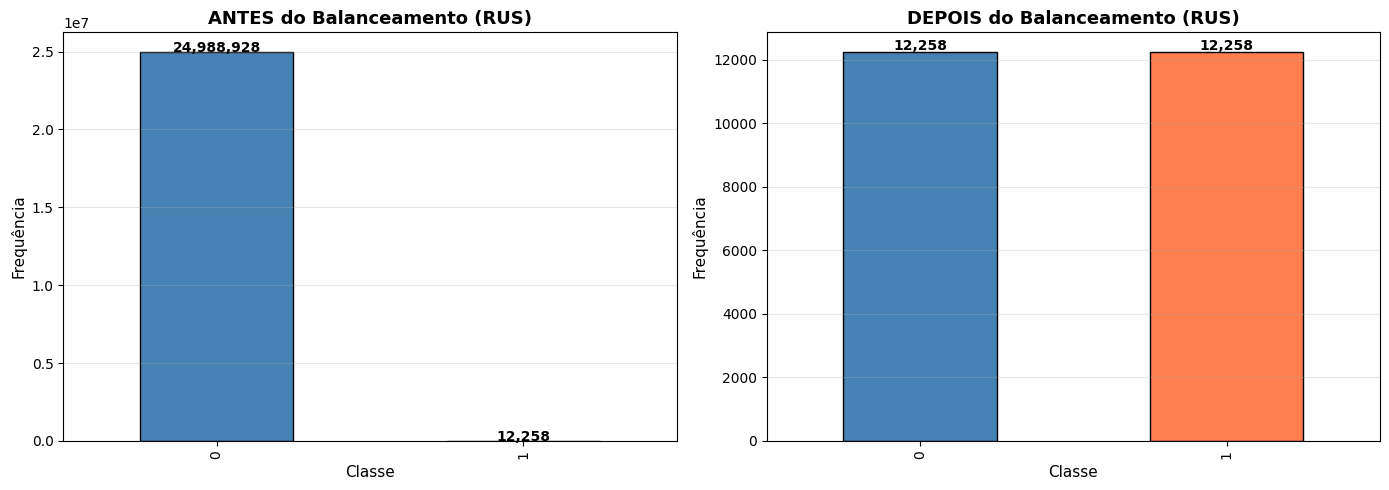

In [18]:
# Aplicar Random Under Sampling
print("="*80)
print("BALANCEAMENTO COM RANDOM UNDER SAMPLING (RUS)")
print("="*80)

# Criar o sampler
rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Aplicar RUS nos dados de treino
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

print(f"\n📊 Dados ANTES do balanceamento:")
print(f"   Shape: {X_train.shape}")
print(f"   Distribuição: {y_train.value_counts().to_dict()}")

print(f"\n📊 Dados DEPOIS do balanceamento:")
print(f"   Shape: {X_train_balanced.shape}")
print(f"   Distribuição: {y_train_balanced.value_counts().to_dict()}")

# Calcular percentual de amostras removidas
samples_removed = len(X_train) - len(X_train_balanced)
pct_removed = (samples_removed / len(X_train)) * 100

print(f"\n📊 Estatísticas do Balanceamento:")
print(f"   Amostras originais: {len(X_train):,}")
print(f"   Amostras balanceadas: {len(X_train_balanced):,}")
print(f"   Amostras removidas: {samples_removed:,} ({pct_removed:.2f}%)")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes do balanceamento
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('ANTES do Balanceamento (RUS)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(y_train.value_counts().sort_index()):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Depois do balanceamento
y_train_balanced.value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('DEPOIS do Balanceamento (RUS)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(y_train_balanced.value_counts().sort_index()):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Criação de Pipelines

Criando pipelines completos para evitar data leakage entre treino e teste.

In [19]:
# Criar pipelines com diferentes modelos
print("="*80)
print("CRIAÇÃO DE PIPELINES")
print("="*80)

# Dicionário para armazenar os pipelines
pipelines = {}

# 1. Logistic Regression
pipelines['Logistic Regression'] = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced'
    ))
])

# 2. Random Forest
pipelines['Random Forest'] = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# 3. Gradient Boosting
pipelines['Gradient Boosting'] = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8
    ))
])

# 4. XGBoost
pipelines['XGBoost'] = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        eval_metric='logloss',
        enable_categorical=False
    ))
])

# 5. LightGBM
pipelines['LightGBM'] = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        verbose=-1
    ))
])

print(f"\n✅ {len(pipelines)} pipelines criados com sucesso!")
print(f"\nModelos disponíveis:")
for i, name in enumerate(pipelines.keys(), 1):
    print(f"   {i}. {name}")

CRIAÇÃO DE PIPELINES

✅ 5 pipelines criados com sucesso!

Modelos disponíveis:
   1. Logistic Regression
   2. Random Forest
   3. Gradient Boosting
   4. XGBoost
   5. LightGBM


## 5. Treinamento dos Modelos

Treinando todos os modelos nos dados balanceados.

In [20]:
# Treinar todos os modelos
print("="*80)
print("TREINAMENTO DOS MODELOS")
print("="*80)

# Dicionário para armazenar modelos treinados e tempos
trained_models = {}
training_times = {}

for name, pipeline in pipelines.items():
    print(f"\n🔄 Treinando: {name}...")
    start_time = datetime.now()
    
    try:
        # Treinar o pipeline completo (RUS + Scaler + Model)
        pipeline.fit(X_train, y_train)
        
        # Calcular tempo de treinamento
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Armazenar modelo e tempo
        trained_models[name] = pipeline
        training_times[name] = training_time
        
        print(f"   ✅ Treinamento concluído em {training_time:.2f} segundos")
        
    except Exception as e:
        print(f"   ❌ Erro no treinamento: {str(e)}")

print(f"\n" + "="*80)
print(f"✅ TREINAMENTO CONCLUÍDO!")
print(f"   Total de modelos treinados: {len(trained_models)}")
print("="*80)

# Resumo dos tempos de treinamento
print(f"\n📊 Tempos de Treinamento:")
for name, time in sorted(training_times.items(), key=lambda x: x[1]):
    print(f"   {name}: {time:.2f}s")

TREINAMENTO DOS MODELOS

🔄 Treinando: Logistic Regression...
   ✅ Treinamento concluído em 2.45 segundos

🔄 Treinando: Random Forest...
   ✅ Treinamento concluído em 2.84 segundos

🔄 Treinando: Gradient Boosting...
   ✅ Treinamento concluído em 8.84 segundos

🔄 Treinando: XGBoost...
   ✅ Treinamento concluído em 2.65 segundos

🔄 Treinando: LightGBM...
   ✅ Treinamento concluído em 4.40 segundos

✅ TREINAMENTO CONCLUÍDO!
   Total de modelos treinados: 5

📊 Tempos de Treinamento:
   Logistic Regression: 2.45s
   XGBoost: 2.65s
   Random Forest: 2.84s
   LightGBM: 4.40s
   Gradient Boosting: 8.84s


## 6. Avaliação nos Dados de Treino

Avaliando o desempenho dos modelos nos dados de treino.

AVALIAÇÃO NOS DADOS DE TREINO

📊 Avaliando: Logistic Regression
   Accuracy:  0.7342
   Precision: 0.0014
   Recall:    0.7690
   F1-Score:  0.0028
   ROC-AUC:   0.8046
   PR-AUC:    0.0016

📊 Avaliando: Random Forest
   Accuracy:  0.7522
   Precision: 0.0018
   Recall:    0.9268
   F1-Score:  0.0037
   ROC-AUC:   0.9011
   PR-AUC:    0.0070

📊 Avaliando: Gradient Boosting
   Accuracy:  0.7600
   Precision: 0.0018
   Recall:    0.8800
   F1-Score:  0.0036
   ROC-AUC:   0.8921
   PR-AUC:    0.0067

📊 Avaliando: XGBoost
   Accuracy:  0.8627
   Precision: 0.0034
   Recall:    0.9425
   F1-Score:  0.0067
   ROC-AUC:   0.9640
   PR-AUC:    0.0387

📊 Avaliando: LightGBM
   Accuracy:  0.8646
   Precision: 0.0034
   Recall:    0.9380
   F1-Score:  0.0067
   ROC-AUC:   0.9620
   PR-AUC:    0.0378

RESUMO DOS RESULTADOS - TREINO
                     Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression  0.734200   0.001400 0.769000  0.002800 0.804600 0.001600
Random Forest

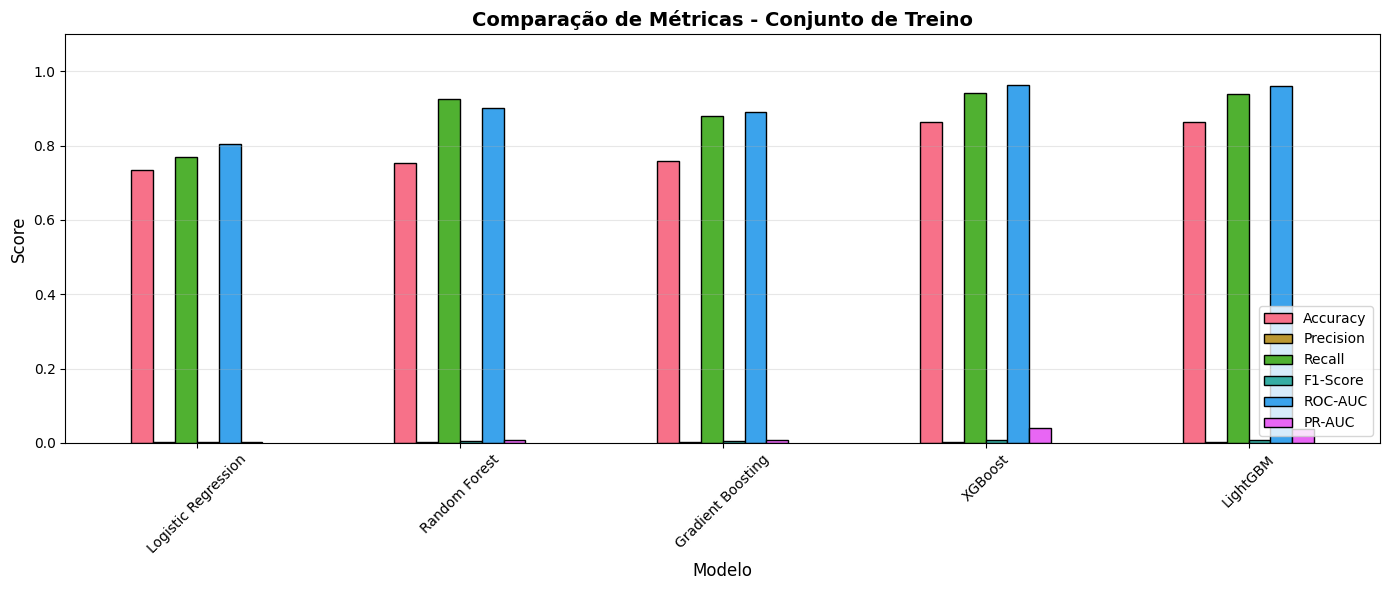

In [21]:
# Função para calcular métricas
def calculate_metrics(y_true, y_pred, y_pred_proba):
    """
    Calcula todas as métricas de avaliação
    """
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba),
        'PR-AUC': average_precision_score(y_true, y_pred_proba)
    }

# Avaliar modelos no conjunto de treino
print("="*80)
print("AVALIAÇÃO NOS DADOS DE TREINO")
print("="*80)

train_results = {}

for name, model in trained_models.items():
    print(f"\n📊 Avaliando: {name}")
    
    # Fazer predições
    y_train_pred = model.predict(X_train)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    
    # Calcular métricas
    metrics = calculate_metrics(y_train, y_train_pred, y_train_pred_proba)
    train_results[name] = metrics
    
    # Mostrar métricas
    print(f"   Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"   Precision: {metrics['Precision']:.4f}")
    print(f"   Recall:    {metrics['Recall']:.4f}")
    print(f"   F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"   ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    print(f"   PR-AUC:    {metrics['PR-AUC']:.4f}")

# Criar DataFrame com resultados
df_train_results = pd.DataFrame(train_results).T
df_train_results = df_train_results.round(4)

print("\n" + "="*80)
print("RESUMO DOS RESULTADOS - TREINO")
print("="*80)
print(df_train_results.to_string())

# Visualização das métricas
fig, ax = plt.subplots(figsize=(14, 6))

df_train_results.plot(kind='bar', ax=ax, rot=45, edgecolor='black')
ax.set_title('Comparação de Métricas - Conjunto de Treino', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 7. Avaliação nos Dados OOT (Out-of-Time)

Avaliando o desempenho dos modelos nos dados OOT para verificar a generalização.

AVALIAÇÃO NOS DADOS OOT (OUT-OF-TIME)

📊 Avaliando: Logistic Regression
   Accuracy:  0.3129
   Precision: 0.0007
   Recall:    0.7592
   F1-Score:  0.0013
   ROC-AUC:   0.5382
   PR-AUC:    0.0007

📊 Avaliando: Random Forest
   Accuracy:  0.4414
   Precision: 0.0010
   Recall:    0.9569
   F1-Score:  0.0021
   ROC-AUC:   0.8492
   PR-AUC:    0.0060

📊 Avaliando: Gradient Boosting
   Accuracy:  0.6203
   Precision: 0.0011
   Recall:    0.6968
   F1-Score:  0.0022
   ROC-AUC:   0.7338
   PR-AUC:    0.0032

📊 Avaliando: XGBoost
   Accuracy:  0.5976
   Precision: 0.0014
   Recall:    0.9379
   F1-Score:  0.0028
   ROC-AUC:   0.8790
   PR-AUC:    0.0067

📊 Avaliando: LightGBM
   Accuracy:  0.8250
   Precision: 0.0024
   Recall:    0.6942
   F1-Score:  0.0048
   ROC-AUC:   0.8630
   PR-AUC:    0.0065

RESUMO DOS RESULTADOS - OOT
                     Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression  0.312900   0.000700 0.759200  0.001300 0.538200 0.000700
Random F

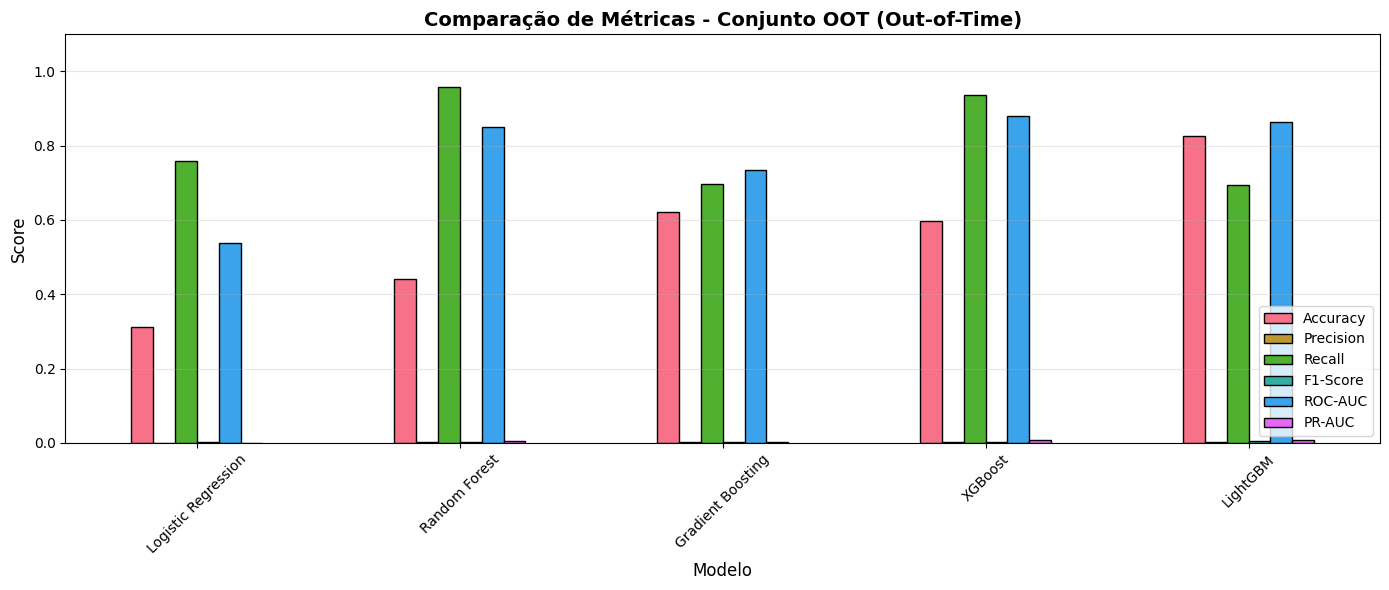

In [22]:
# Avaliar modelos no conjunto OOT
print("="*80)
print("AVALIAÇÃO NOS DADOS OOT (OUT-OF-TIME)")
print("="*80)

oot_results = {}

for name, model in trained_models.items():
    print(f"\n📊 Avaliando: {name}")
    
    # Fazer predições
    y_oot_pred = model.predict(X_oot)
    y_oot_pred_proba = model.predict_proba(X_oot)[:, 1]
    
    # Calcular métricas
    metrics = calculate_metrics(y_oot, y_oot_pred, y_oot_pred_proba)
    oot_results[name] = metrics
    
    # Mostrar métricas
    print(f"   Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"   Precision: {metrics['Precision']:.4f}")
    print(f"   Recall:    {metrics['Recall']:.4f}")
    print(f"   F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"   ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    print(f"   PR-AUC:    {metrics['PR-AUC']:.4f}")

# Criar DataFrame com resultados
df_oot_results = pd.DataFrame(oot_results).T
df_oot_results = df_oot_results.round(4)

print("\n" + "="*80)
print("RESUMO DOS RESULTADOS - OOT")
print("="*80)
print(df_oot_results.to_string())

# Visualização das métricas
fig, ax = plt.subplots(figsize=(14, 6))

df_oot_results.plot(kind='bar', ax=ax, rot=45, edgecolor='black')
ax.set_title('Comparação de Métricas - Conjunto OOT (Out-of-Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 8. Comparação Treino vs OOT

Comparando o desempenho entre treino e OOT para detectar overfitting.

COMPARAÇÃO: TREINO vs OOT

📊 Logistic Regression:
  Métrica   Treino      OOT  Diferença Overfitting
 Accuracy 0.734166 0.312868   0.421298      ⚠️ Sim
Precision 0.001417 0.000668   0.000748       ✅ Não
   Recall 0.768967 0.759186   0.009781       ✅ Não
 F1-Score 0.002829 0.001336   0.001493       ✅ Não
  ROC-AUC 0.804557 0.538244   0.266313      ⚠️ Sim
   PR-AUC 0.001581 0.000660   0.000921       ✅ Não

📊 Random Forest:
  Métrica   Treino      OOT  Diferença Overfitting
 Accuracy 0.752160 0.441360   0.310799      ⚠️ Sim
Precision 0.001830 0.001036   0.000795       ✅ Não
   Recall 0.926823 0.956913  -0.030089       ✅ Não
 F1-Score 0.003654 0.002069   0.001584       ✅ Não
  ROC-AUC 0.901118 0.849225   0.051892       ✅ Não
   PR-AUC 0.006988 0.006036   0.000952       ✅ Não

📊 Gradient Boosting:
  Métrica   Treino      OOT  Diferença Overfitting
 Accuracy 0.760039 0.620304   0.139735      ⚠️ Sim
Precision 0.001795 0.001110   0.000685       ✅ Não
   Recall 0.879997 0.696801   0.183195     

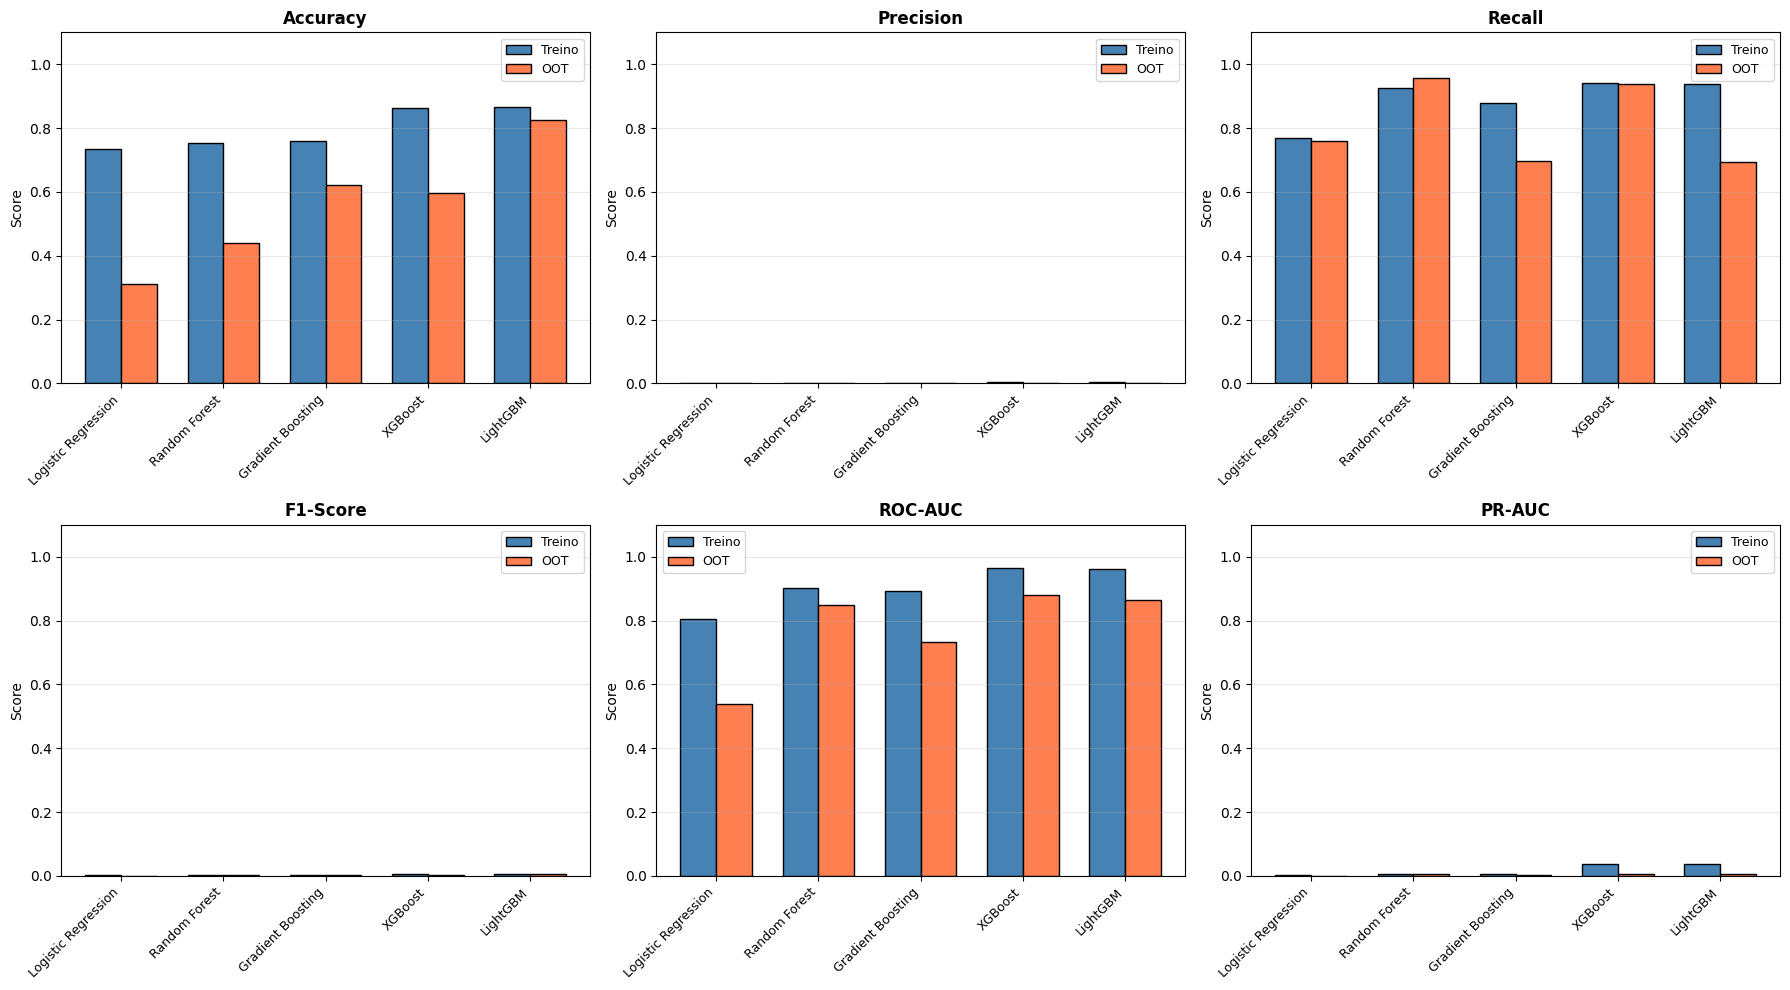

In [23]:
# Comparação Treino vs OOT
print("="*80)
print("COMPARAÇÃO: TREINO vs OOT")
print("="*80)

# Criar DataFrame comparativo
comparison_data = []

for model_name in trained_models.keys():
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']:
        train_value = train_results[model_name][metric]
        oot_value = oot_results[model_name][metric]
        diff = train_value - oot_value
        
        comparison_data.append({
            'Modelo': model_name,
            'Métrica': metric,
            'Treino': train_value,
            'OOT': oot_value,
            'Diferença': diff,
            'Overfitting': '⚠️ Sim' if diff > 0.1 else '✅ Não'
        })

df_comparison = pd.DataFrame(comparison_data)

# Mostrar comparação para cada modelo
for model_name in trained_models.keys():
    print(f"\n📊 {model_name}:")
    model_comp = df_comparison[df_comparison['Modelo'] == model_name]
    print(model_comp[['Métrica', 'Treino', 'OOT', 'Diferença', 'Overfitting']].to_string(index=False))

# Visualização comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Dados para o gráfico
    models = list(trained_models.keys())
    train_scores = [train_results[m][metric] for m in models]
    oot_scores = [oot_results[m][metric] for m in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    ax.bar(x - width/2, train_scores, width, label='Treino', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, oot_scores, width, label='OOT', color='coral', edgecolor='black')
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 9. Matrizes de Confusão

Visualizando as matrizes de confusão para cada modelo.

MATRIZES DE CONFUSÃO - OOT


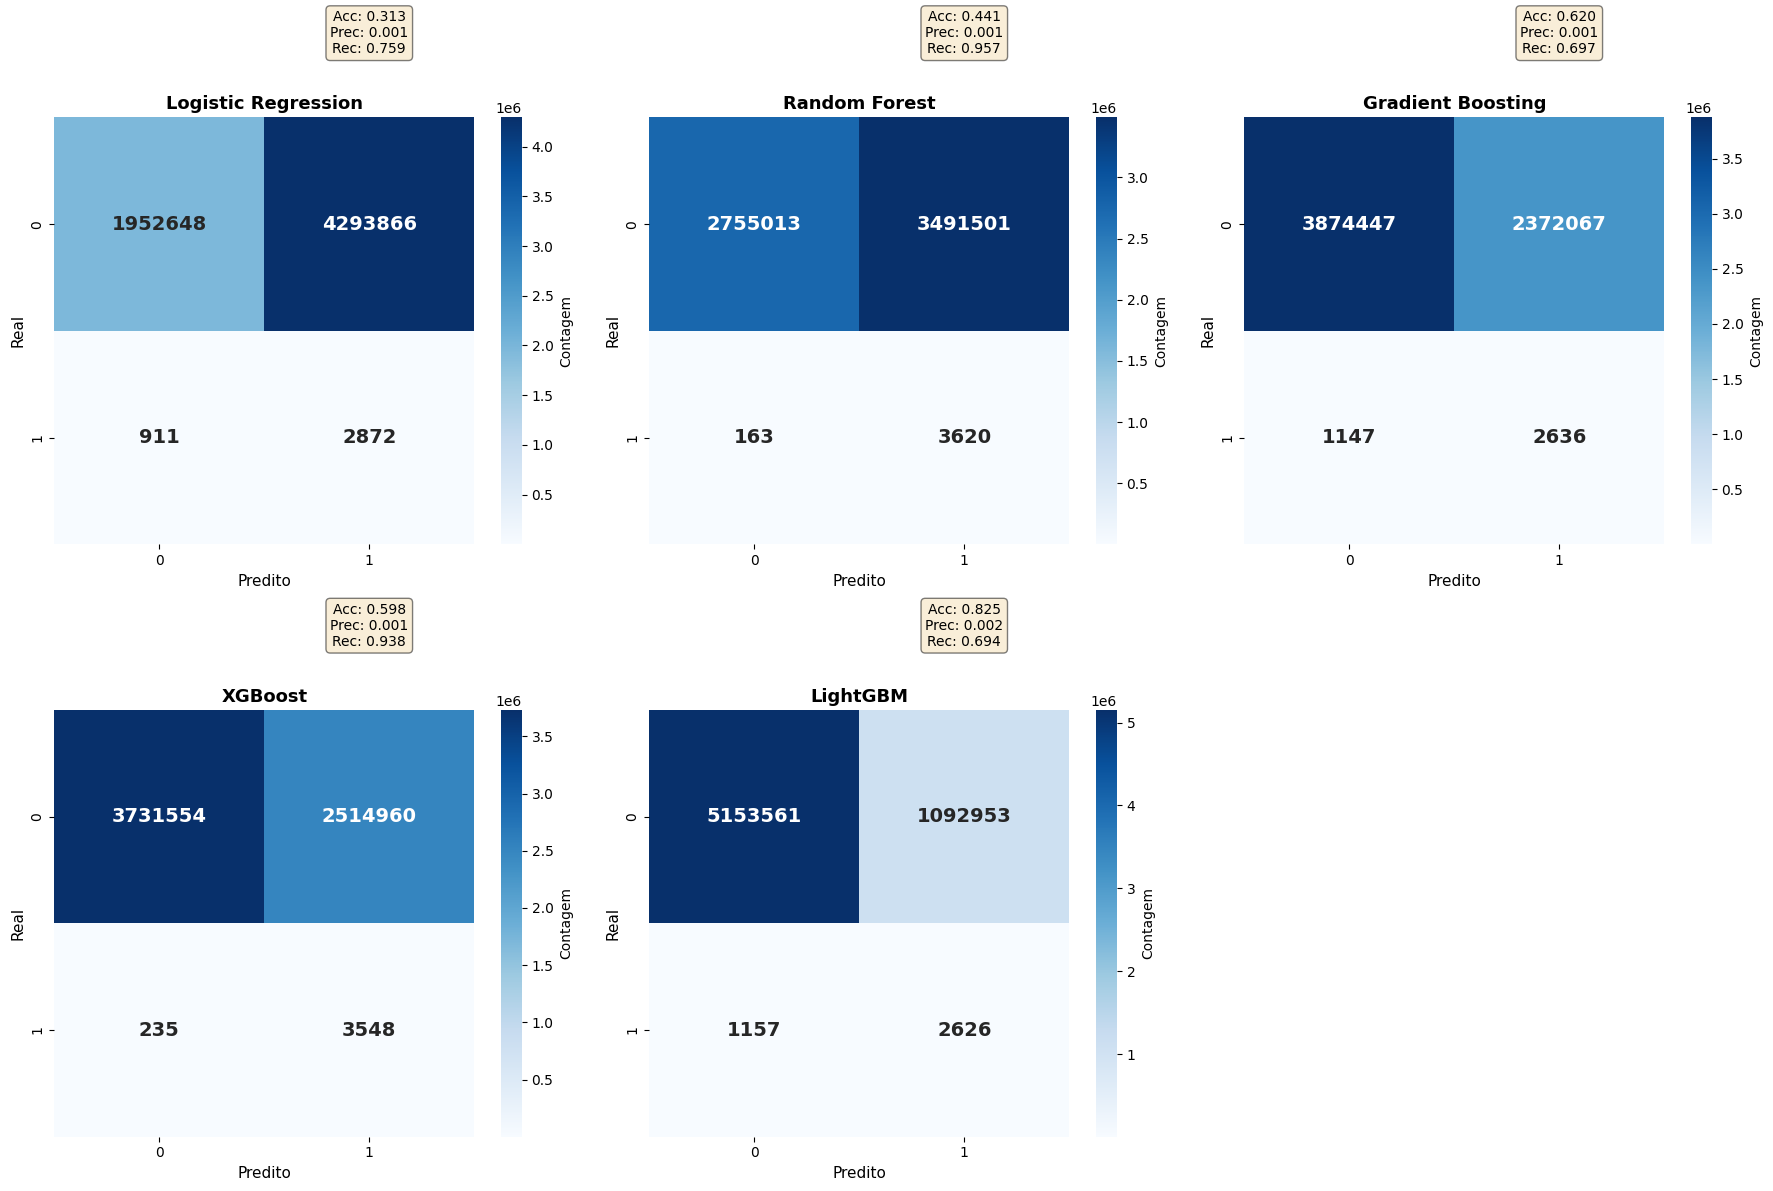

In [24]:
# Plotar matrizes de confusão
print("="*80)
print("MATRIZES DE CONFUSÃO - OOT")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    
    # Predições
    y_oot_pred = model.predict(X_oot)
    
    # Matriz de confusão
    cm = confusion_matrix(y_oot, y_oot_pred)
    
    # Plotar
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Contagem'},
                annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    
    # Adicionar métricas na matriz
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}'
    ax.text(1.5, -0.3, text, fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remover eixo extra se houver
if len(trained_models) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 10. Curvas ROC

Plotando as curvas ROC para todos os modelos.

CURVAS ROC


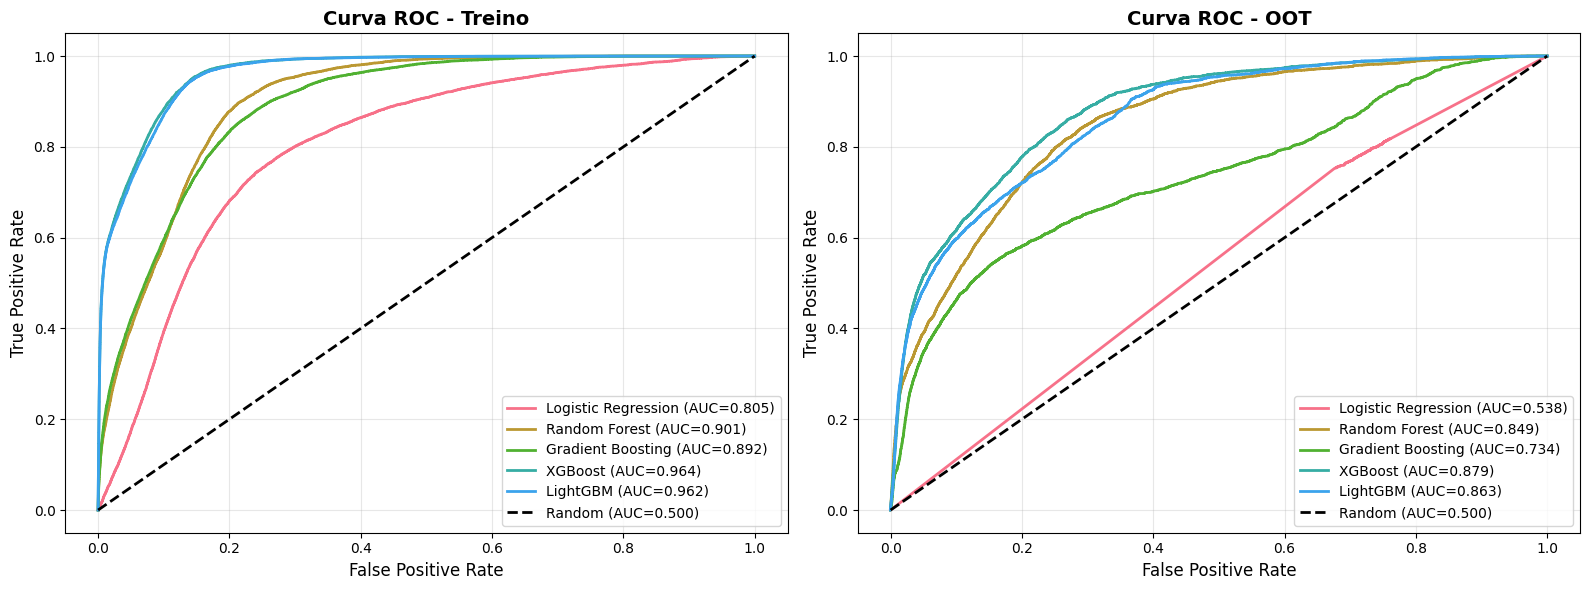

In [25]:
# Plotar curvas ROC
print("="*80)
print("CURVAS ROC")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC - Treino
ax = axes[0]
for name, model in trained_models.items():
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_train_pred_proba)
    auc = roc_auc_score(y_train, y_train_pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=2)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC - Treino', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# Curva ROC - OOT
ax = axes[1]
for name, model in trained_models.items():
    y_oot_pred_proba = model.predict_proba(X_oot)[:, 1]
    fpr, tpr, _ = roc_curve(y_oot, y_oot_pred_proba)
    auc = roc_auc_score(y_oot, y_oot_pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=2)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC - OOT', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Curvas Precision-Recall

Plotando as curvas Precision-Recall para todos os modelos.

CURVAS PRECISION-RECALL


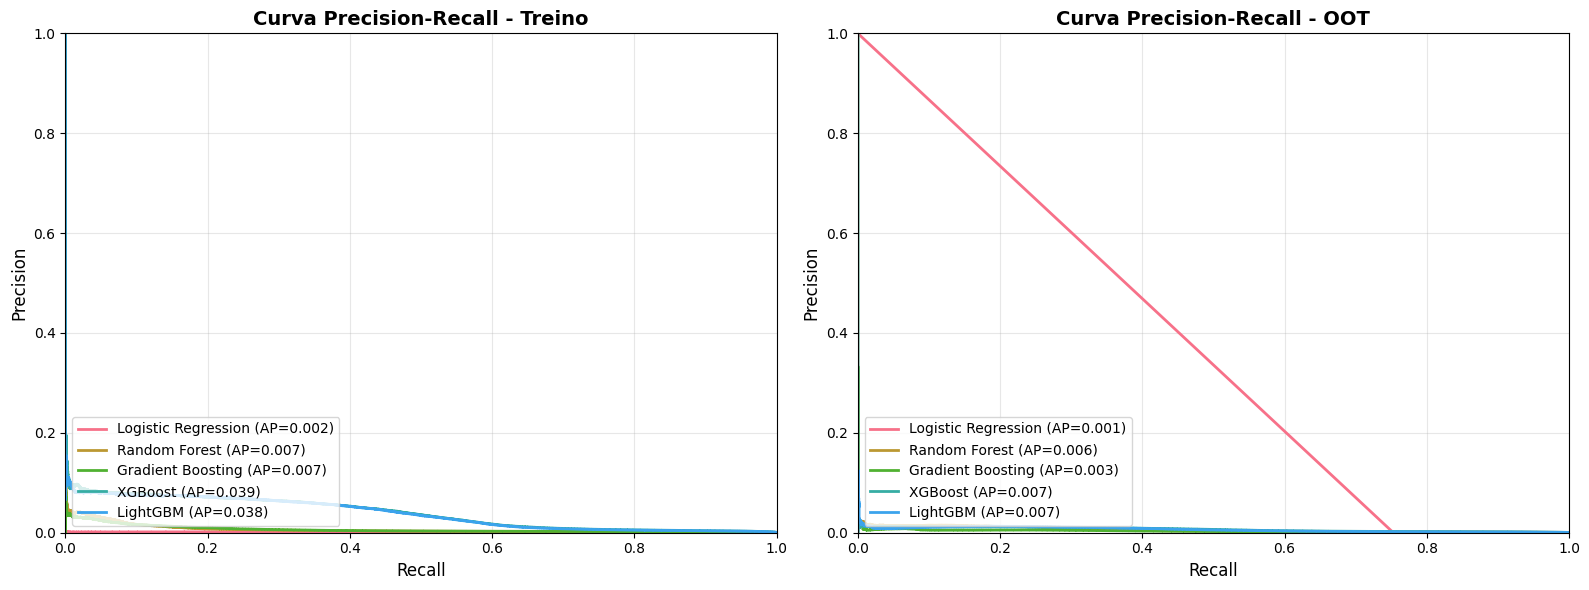

In [26]:
# Plotar curvas Precision-Recall
print("="*80)
print("CURVAS PRECISION-RECALL")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva PR - Treino
ax = axes[0]
for name, model in trained_models.items():
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    precision, recall, _ = precision_recall_curve(y_train, y_train_pred_proba)
    pr_auc = average_precision_score(y_train, y_train_pred_proba)
    ax.plot(recall, precision, label=f'{name} (AP={pr_auc:.3f})', linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall - Treino', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Curva PR - OOT
ax = axes[1]
for name, model in trained_models.items():
    y_oot_pred_proba = model.predict_proba(X_oot)[:, 1]
    precision, recall, _ = precision_recall_curve(y_oot, y_oot_pred_proba)
    pr_auc = average_precision_score(y_oot, y_oot_pred_proba)
    ax.plot(recall, precision, label=f'{name} (AP={pr_auc:.3f})', linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall - OOT', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 12. Feature Importance

Analisando a importância das features para os modelos baseados em árvores.

FEATURE IMPORTANCE

📊 Top 10 Features - Random Forest:
   Amount Received: 0.1434
   Amount Paid: 0.1392
   Timestamp_freq_enc: 0.1098
   Account Number_freq_enc: 0.0985
   From Account_freq_enc: 0.0936
   From Entity Name_freq_enc: 0.0822
   From Entity ID_freq_enc: 0.0730
   From Bank Name_freq_enc: 0.0523
   To Entity Name_freq_enc: 0.0368
   To Entity ID_freq_enc: 0.0347

📊 Top 10 Features - Gradient Boosting:
   Amount Received: 0.2055
   Account Number_freq_enc: 0.1334
   Timestamp_freq_enc: 0.1221
   From Account_freq_enc: 0.1134
   From Bank Name_freq_enc: 0.0879
   From Entity Name_freq_enc: 0.0607
   From Entity ID_freq_enc: 0.0468
   Amount Paid: 0.0434
   To Entity Name_freq_enc: 0.0315
   Payment Currency_target_enc: 0.0312

📊 Top 10 Features - XGBoost:
   From Entity ID_freq_enc: 0.1864
   From Account_freq_enc: 0.1331
   Account Number_To_freq_enc: 0.1091
   From Entity Name_freq_enc: 0.0786
   Account Number_freq_enc: 0.0755
   Timestamp_freq_enc: 0.0699
   To Account_f

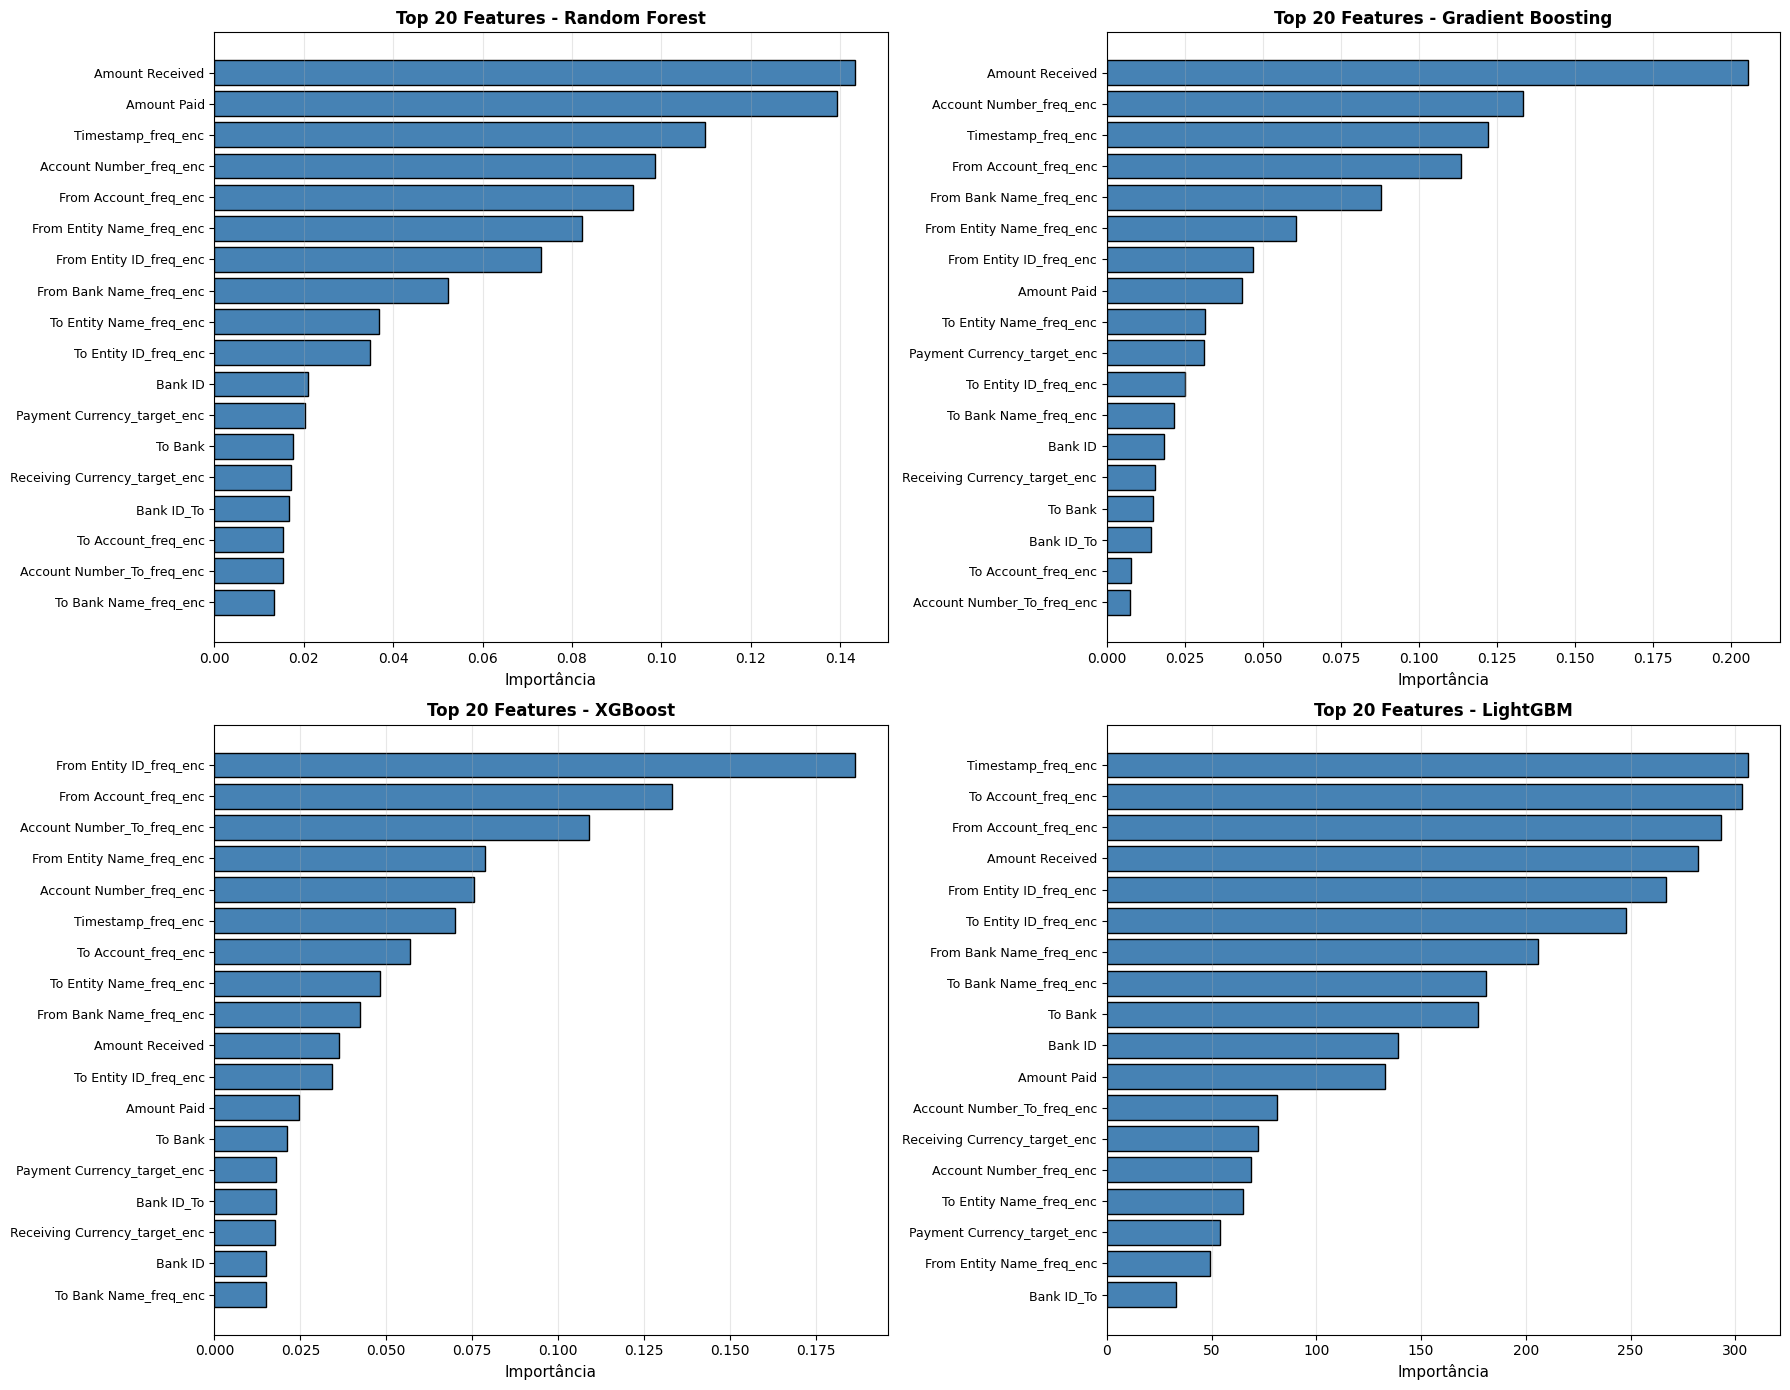

In [27]:
# Feature Importance para modelos baseados em árvores
print("="*80)
print("FEATURE IMPORTANCE")
print("="*80)

# Modelos que suportam feature importance
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, model_name in enumerate(tree_models):
    if model_name in trained_models:
        ax = axes[idx]
        
        # Obter o classificador do pipeline
        classifier = trained_models[model_name].named_steps['classifier']
        
        # Obter feature importance
        feature_importance = classifier.feature_importances_
        
        # Criar DataFrame
        importance_df = pd.DataFrame({
            'feature': X_train.columns,
            'importance': feature_importance
        }).sort_values('importance', ascending=False).head(20)
        
        # Plotar
        ax.barh(range(len(importance_df)), importance_df['importance'], color='steelblue', edgecolor='black')
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df['feature'], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Importância', fontsize=11)
        ax.set_title(f'Top 20 Features - {model_name}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, axis='x')
        
        print(f"\n📊 Top 10 Features - {model_name}:")
        for i, row in importance_df.head(10).iterrows():
            print(f"   {row['feature']}: {row['importance']:.4f}")

plt.tight_layout()
plt.show()

## 13. Seleção do Melhor Modelo

Identificando o melhor modelo com base nas métricas no conjunto OOT.

In [28]:
# Selecionar melhor modelo
print("="*80)
print("SELEÇÃO DO MELHOR MODELO")
print("="*80)

# Criar ranking para cada métrica
rankings = {}

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']:
    sorted_models = df_oot_results.sort_values(metric, ascending=False)
    rankings[metric] = sorted_models.index.tolist()
    
    print(f"\n📊 Ranking por {metric}:")
    for i, model in enumerate(sorted_models.index, 1):
        score = sorted_models.loc[model, metric]
        print(f"   {i}. {model}: {score:.4f}")

# Calcular score agregado (média dos rankings)
ranking_scores = {}

for model in trained_models.keys():
    positions = [rankings[metric].index(model) + 1 for metric in rankings.keys()]
    avg_position = np.mean(positions)
    ranking_scores[model] = avg_position

# Ordenar por melhor posição média
best_models = sorted(ranking_scores.items(), key=lambda x: x[1])

print(f"\n" + "="*80)
print("RANKING GERAL (baseado na posição média em todas as métricas)")
print("="*80)

for i, (model, avg_pos) in enumerate(best_models, 1):
    print(f"{i}. {model}: Posição média = {avg_pos:.2f}")

# Melhor modelo
best_model_name = best_models[0][0]
best_model = trained_models[best_model_name]

print(f"\n" + "="*80)
print(f"🏆 MELHOR MODELO: {best_model_name}")
print("="*80)

print(f"\n📊 Performance no OOT:")
for metric, value in oot_results[best_model_name].items():
    print(f"   {metric}: {value:.4f}")

SELEÇÃO DO MELHOR MODELO

📊 Ranking por Accuracy:
   1. LightGBM: 0.8250
   2. Gradient Boosting: 0.6203
   3. XGBoost: 0.5976
   4. Random Forest: 0.4414
   5. Logistic Regression: 0.3129

📊 Ranking por Precision:
   1. LightGBM: 0.0024
   2. XGBoost: 0.0014
   3. Gradient Boosting: 0.0011
   4. Random Forest: 0.0010
   5. Logistic Regression: 0.0007

📊 Ranking por Recall:
   1. Random Forest: 0.9569
   2. XGBoost: 0.9379
   3. Logistic Regression: 0.7592
   4. Gradient Boosting: 0.6968
   5. LightGBM: 0.6942

📊 Ranking por F1-Score:
   1. LightGBM: 0.0048
   2. XGBoost: 0.0028
   3. Gradient Boosting: 0.0022
   4. Random Forest: 0.0021
   5. Logistic Regression: 0.0013

📊 Ranking por ROC-AUC:
   1. XGBoost: 0.8790
   2. LightGBM: 0.8630
   3. Random Forest: 0.8492
   4. Gradient Boosting: 0.7338
   5. Logistic Regression: 0.5382

📊 Ranking por PR-AUC:
   1. XGBoost: 0.0067
   2. LightGBM: 0.0065
   3. Random Forest: 0.0060
   4. Gradient Boosting: 0.0032
   5. Logistic Regression: 0.

## 14. Salvamento dos Modelos

Salvando os modelos treinados e resultados.

In [29]:
# Salvar modelos e resultados
import os
import pickle
import json

print("="*80)
print("SALVAMENTO DOS MODELOS E RESULTADOS")
print("="*80)

# Criar diretório
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# 1. Salvar todos os modelos
print(f"\n📁 Salvando modelos...")
for name, model in trained_models.items():
    # Nome do arquivo
    filename = name.replace(' ', '_').lower()
    filepath = os.path.join(models_dir, f'{filename}_model.pkl')
    
    # Salvar modelo
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    
    print(f"   ✅ {name} salvo em: {filepath}")

# 2. Salvar melhor modelo separadamente
best_model_path = os.path.join(models_dir, 'best_model.pkl')
with open(best_model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✅ Melhor modelo ({best_model_name}) salvo em: {best_model_path}")

# 3. Salvar resultados em CSV
results_dir = '../data/processed'
os.makedirs(results_dir, exist_ok=True)

# Resultados de treino
train_results_path = os.path.join(results_dir, 'model_results_train.csv')
df_train_results.to_csv(train_results_path)
print(f"✅ Resultados de treino salvos em: {train_results_path}")

# Resultados de OOT
oot_results_path = os.path.join(results_dir, 'model_results_oot.csv')
df_oot_results.to_csv(oot_results_path)
print(f"✅ Resultados de OOT salvos em: {oot_results_path}")

# 4. Salvar informações do treinamento
training_info = {
    'best_model': best_model_name,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models_trained': list(trained_models.keys()),
    'training_times': training_times,
    'train_samples': len(X_train),
    'oot_samples': len(X_oot),
    'features_count': X_train.shape[1],
    'balancing_method': 'Random Under Sampling (RUS)',
    'best_model_metrics': {
        'train': {k: float(v) for k, v in train_results[best_model_name].items()},
        'oot': {k: float(v) for k, v in oot_results[best_model_name].items()}
    }
}

training_info_path = os.path.join(models_dir, 'training_info.json')
with open(training_info_path, 'w') as f:
    json.dump(training_info, f, indent=4)
print(f"✅ Informações de treinamento salvas em: {training_info_path}")

print("\n" + "="*80)
print("✅ SALVAMENTO CONCLUÍDO!")
print("="*80)

SALVAMENTO DOS MODELOS E RESULTADOS

📁 Salvando modelos...
   ✅ Logistic Regression salvo em: ../models\logistic_regression_model.pkl
   ✅ Random Forest salvo em: ../models\random_forest_model.pkl
   ✅ Gradient Boosting salvo em: ../models\gradient_boosting_model.pkl
   ✅ XGBoost salvo em: ../models\xgboost_model.pkl
   ✅ LightGBM salvo em: ../models\lightgbm_model.pkl

✅ Melhor modelo (XGBoost) salvo em: ../models\best_model.pkl
✅ Resultados de treino salvos em: ../data/processed\model_results_train.csv
✅ Resultados de OOT salvos em: ../data/processed\model_results_oot.csv
✅ Informações de treinamento salvas em: ../models\training_info.json

✅ SALVAMENTO CONCLUÍDO!


## 15. Resumo Executivo

Resumo completo de todo o processo de treinamento e avaliação.

In [30]:
# Resumo Executivo
print("="*80)
print("RESUMO EXECUTIVO - TREINAMENTO DE MODELOS")
print("="*80)

print(f"\n1. DADOS UTILIZADOS:")
print(f"   - Treino: {X_train.shape}")
print(f"   - OOT: {X_oot.shape}")
print(f"   - Total de features: {X_train.shape[1]}")

print(f"\n2. BALANCEAMENTO:")
print(f"   - Técnica: Random Under Sampling (RUS)")
print(f"   - Amostras originais: {len(X_train):,}")
print(f"   - Amostras balanceadas: {len(X_train_balanced):,}")
print(f"   - Redução: {((len(X_train) - len(X_train_balanced)) / len(X_train) * 100):.2f}%")

print(f"\n3. MODELOS TREINADOS:")
for i, name in enumerate(trained_models.keys(), 1):
    time = training_times[name]
    print(f"   {i}. {name} (tempo: {time:.2f}s)")

print(f"\n4. MELHOR MODELO:")
print(f"   🏆 {best_model_name}")
print(f"\n   Performance no OOT:")
for metric, value in oot_results[best_model_name].items():
    print(f"      - {metric}: {value:.4f}")

print(f"\n5. ESTRATÉGIAS APLICADAS:")
print(f"   ✅ Pipelines para evitar data leakage")
print(f"   ✅ Balanceamento com RUS")
print(f"   ✅ Padronização de features (quando aplicável)")
print(f"   ✅ Validação em conjunto OOT (Out-of-Time)")
print(f"   ✅ Análise de overfitting")

print(f"\n6. ARQUIVOS GERADOS:")
print(f"   - Modelos treinados: ../models/")
print(f"   - Melhor modelo: best_model.pkl")
print(f"   - Resultados: model_results_train.csv, model_results_oot.csv")
print(f"   - Info de treinamento: training_info.json")

print(f"\n7. PRÓXIMOS PASSOS:")
print(f"   ✅ Análise de erros")
print(f"   ✅ Otimização de hiperparâmetros")
print(f"   ✅ Ensemble de modelos")
print(f"   ✅ Deploy do modelo")
print(f"   ✅ Monitoramento em produção")

# Comparação final dos top 3 modelos
print(f"\n8. TOP 3 MODELOS (baseado no OOT):")
for i, (model, avg_pos) in enumerate(best_models[:3], 1):
    print(f"\n   {i}. {model}")
    for metric, value in oot_results[model].items():
        print(f"      {metric}: {value:.4f}")

print("\n" + "="*80)
print("✅ TREINAMENTO E AVALIAÇÃO CONCLUÍDOS COM SUCESSO!")
print("="*80)

RESUMO EXECUTIVO - TREINAMENTO DE MODELOS

1. DADOS UTILIZADOS:
   - Treino: (25001186, 18)
   - OOT: (6250297, 18)
   - Total de features: 18

2. BALANCEAMENTO:
   - Técnica: Random Under Sampling (RUS)
   - Amostras originais: 25,001,186
   - Amostras balanceadas: 24,516
   - Redução: 99.90%

3. MODELOS TREINADOS:
   1. Logistic Regression (tempo: 2.45s)
   2. Random Forest (tempo: 2.84s)
   3. Gradient Boosting (tempo: 8.84s)
   4. XGBoost (tempo: 2.65s)
   5. LightGBM (tempo: 4.40s)

4. MELHOR MODELO:
   🏆 XGBoost

   Performance no OOT:
      - Accuracy: 0.5976
      - Precision: 0.0014
      - Recall: 0.9379
      - F1-Score: 0.0028
      - ROC-AUC: 0.8790
      - PR-AUC: 0.0067

5. ESTRATÉGIAS APLICADAS:
   ✅ Pipelines para evitar data leakage
   ✅ Balanceamento com RUS
   ✅ Padronização de features (quando aplicável)
   ✅ Validação em conjunto OOT (Out-of-Time)
   ✅ Análise de overfitting

6. ARQUIVOS GERADOS:
   - Modelos treinados: ../models/
   - Melhor modelo: best_model.pk